# DATA620-W6

Ana Collado

> **Note**
>
> [Here is a
> dataset](http://vlado.fmf.uni-lj.si/pub/networks/data/ucinet/ucidata.htm#davis)
> that shows a simple 2-node network: the attendance of 18 Southern
> Women at 14 social events.
>
> Small “musty” datasets like that from this 1941 study have proven very
> valuable in testing and comparing new network algorithms.
>
> [Click here for Python code to create
> dataset](https://networkx.github.io/documentation/stable/auto_examples/algorithms/plot_davis_club.html)
>
> **What can you infer about the relationships between (1) the women,
> and (2) the social events?**

# Two Mode Networks- Davis Social Southern Club Women

In [1]:
import networkx as nx
from networkx.algorithms import bipartite
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Data Load

The data can be imported through NetworkX.

In [2]:
graph1= nx.davis_southern_women_graph()

I’ll add some color to the nodes to differentiate between event and
person.

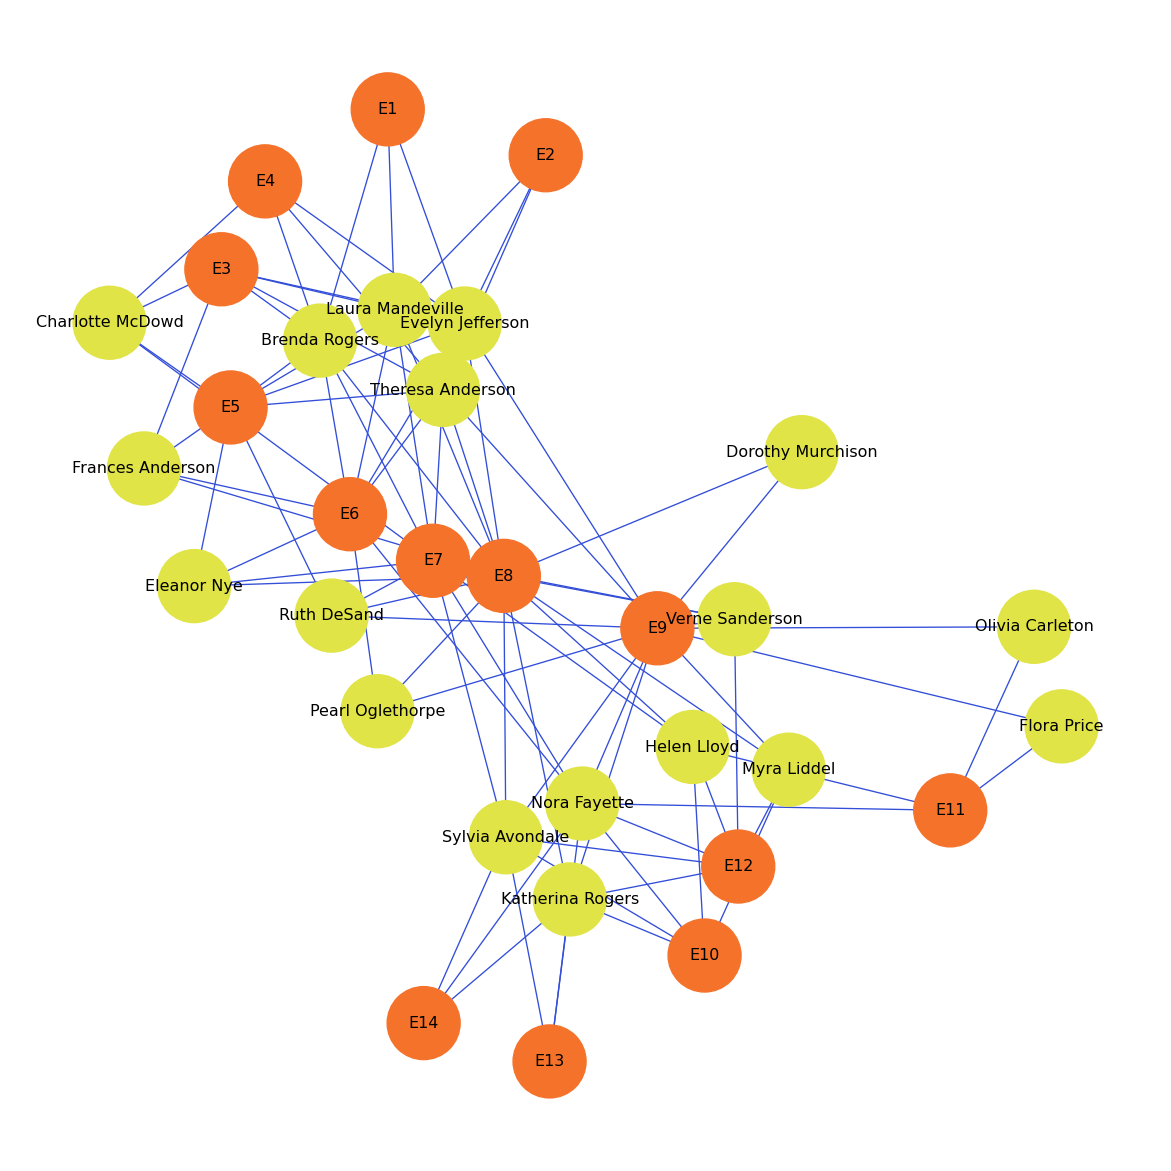

In [3]:
#--adding some distinction--
nodecolor=["#E0E446" if graph1.nodes[n]["bipartite"]== 0 else "#F5722B" for n in graph1.nodes()]

#-- visualizing the graph--
pos= nx.spring_layout(graph1, seed=212)
plt.figure(figsize= (12,12))
nx.draw(graph1, with_labels=True, node_color= nodecolor, node_size=3000, edge_color= "#334ED8", font_size=12, pos=pos)
plt.show()

While it may be tempting to assume relationships (because of clusters of
women in the graph), the the raw graph is really only depicting each
woman’s relationship to an event, not relationships between the women.
To infer about relationships, the graph must be changed into a one-mode
network.

First I’ll create a matrix. The events should be the columns and the
rows will be the women. Attendance will appear as a 1 or a 0. I’ll
create the data frame from the graph created and and go from there.

In [4]:
#-- changing graph edges to df--
edges1= nx.to_pandas_edgelist(graph1)

In [5]:
#-- changing to df and checking whats what--
nodes1= pd.DataFrame.from_dict(dict(graph1.nodes(data=True)), orient= "index")
nodes1= nodes1.reset_index()
nodes1.columns= ["Node", "Bipartite"]
nodes1

In [6]:
#-- separateing the nodes--
people= nodes1[nodes1["Bipartite"]== 0]["Node"].tolist()
events= nodes1[nodes1["Bipartite"]== 1]["Node"].tolist()

#--creating the matrix--
matrix_a= edges1.pivot_table(index="source", columns="target", aggfunc=len, fill_value=0)
matrix_a

`matrix_a` shows what each woman’s attendance is in relation to the
events; who attended what.

$$woman \ \times \ event  $$  
  
From here we’ll multiply the matrix by its transpose. The matrix’s
transpose would each event in relation to who attended.

$$
event\ \times \ woman
$$

So in multiplying matirx_a by its transpose, we get what overlaps, or
the women’s shared connections. Each value is how many events a pair
attended together.

$$
woman \ \times \ woman
$$

In [7]:
relationships= matrix_a @ matrix_a.T
relationships

Now we have the foundation for making assumptions about the social
network of the women. I’ll remove the women’s relationship with
themselves (diagonal values) because it’ll overpower my visualizations.

I’ll visualize the graph:

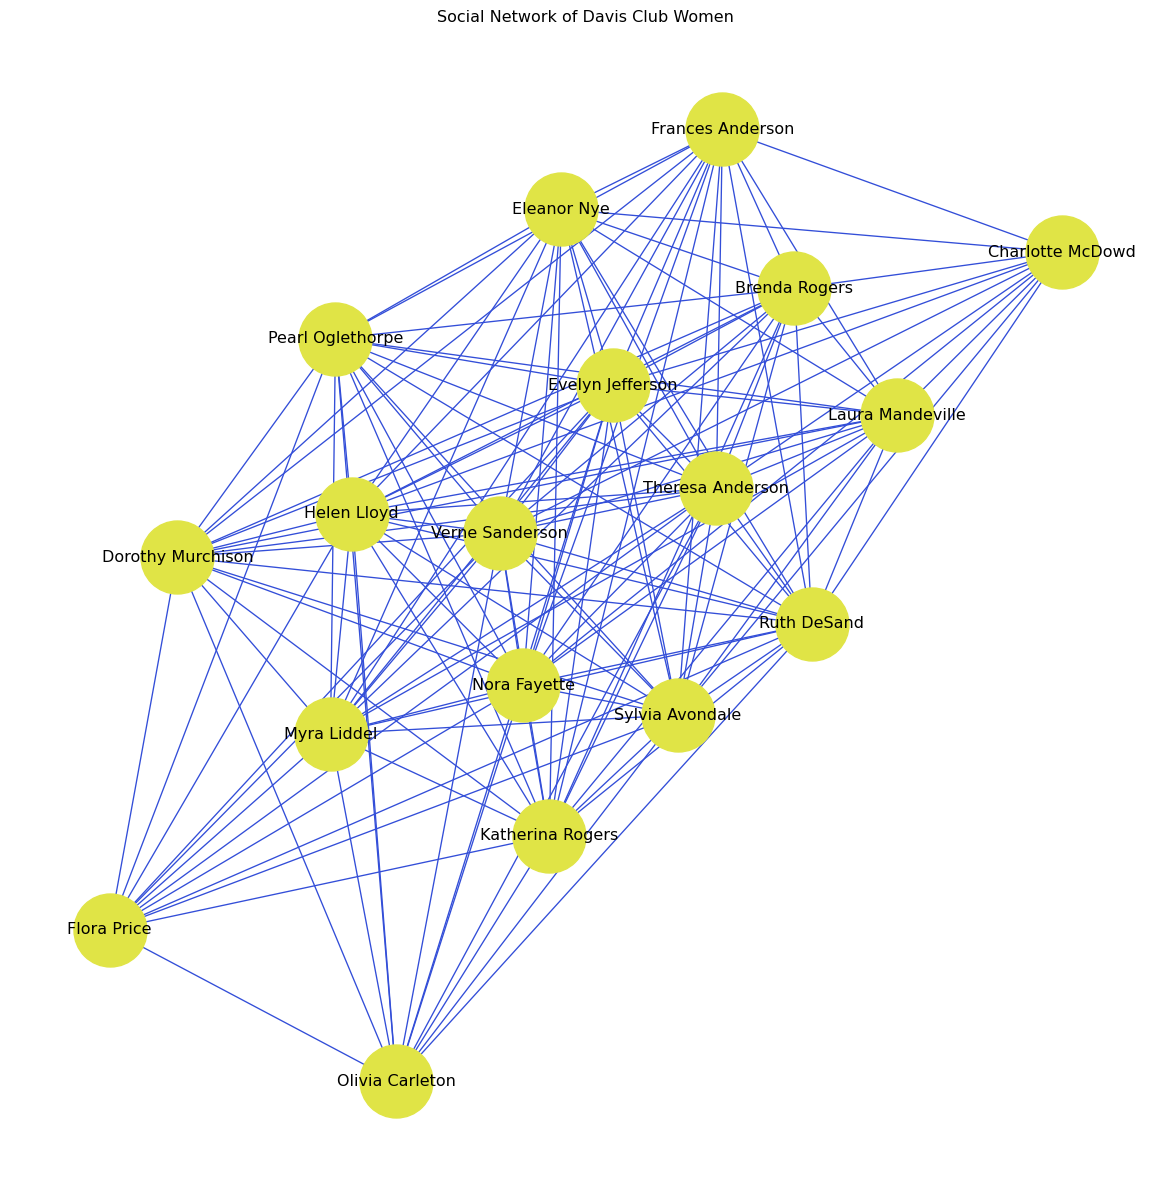

In [8]:
#-- filling the diagonal of matrix--
np.fill_diagonal(relationships.values, 0)
social_club= nx.from_pandas_adjacency(relationships)

#--visualizing--
plt.figure(figsize= (12,12))
nx.draw(social_club, with_labels=True, node_color= "#E0E446", node_size=3000, edge_color= "#334ED8", font_size=12)
plt.title("Social Network of Davis Club Women")
plt.show()

Chapter 5 of Social Network Analysis for Startups (pg 104) defines a
function for whats called the **Island Method**. This method basically
isolates the connections by weight, creating “islands” of strongly
connected networks.

In [9]:
#-- chapter 5 function--
def trim_edges(G, weight=1):
    G2= nx.Graph()
    for u, v, d in G.edges(data=True):
        if d["weight"] > weight:
            G2.add_edge(u, v, **d)
    return G2

The distribution of the treshold/weights will help determining what
number to select for the trimming function.

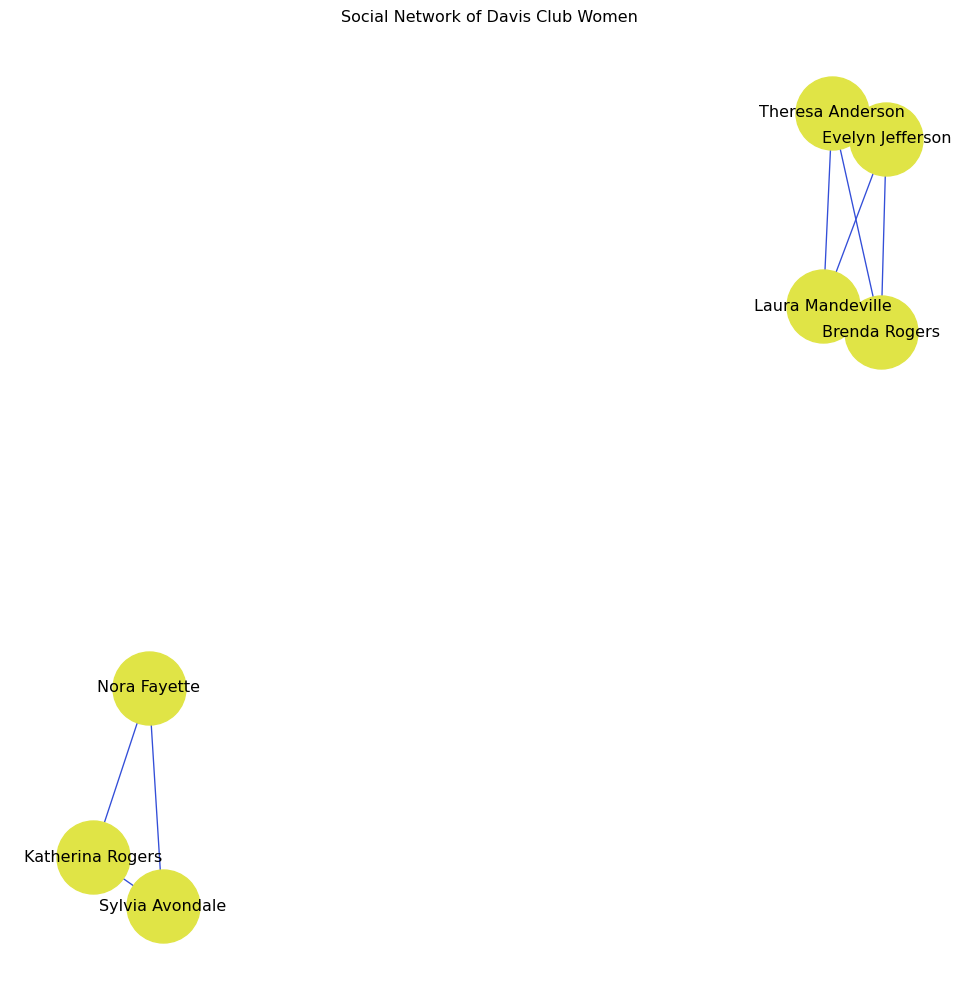

In [10]:
#--determining threshold to use in func--
weights= list(nx.get_edge_attributes(social_club, "weight").values())
pd.Series(weights).value_counts().sort_index()

#-- running the function--
trimmed= trim_edges(social_club, weight= 4)

#--visualizing--
plt.figure(figsize= (10,10))
nx.draw(trimmed, with_labels=True, node_size=3000, node_color= "#E0E446", edge_color= "#334ED8", font_size=12)
plt.title("Social Network of Davis Club Women")
plt.show()

Most edges are gathered at threshold 1 and 2, selecting 3 or 4 as the
threshold would be best.

The new graph shows the most central social circles within the Davis
club.

In [11]:
social_edges= nx.to_pandas_edgelist(social_club).sort_values("weight", ascending=False)
print(social_edges.head(5))

               source            target  weight
63   Evelyn Jefferson  Theresa Anderson       7
7       Brenda Rogers  Laura Mandeville       6
3       Brenda Rogers  Evelyn Jefferson       6
101  Katherina Rogers   Sylvia Avondale       6
56   Evelyn Jefferson  Laura Mandeville       6

Evelyn and Brenda appear twice as sources. We can infer Evelyn, Brenda,
and Katherina are central and important in this social club. The islands
depicted Evelyn and Brenda are in one social circle, and Katerina is
central to another island that includes Sylvia and Nora.

### Event Networks

To make inferences about the events, we’ll flip the matrix \* matrix
transpose and quickly redo the same analysis.

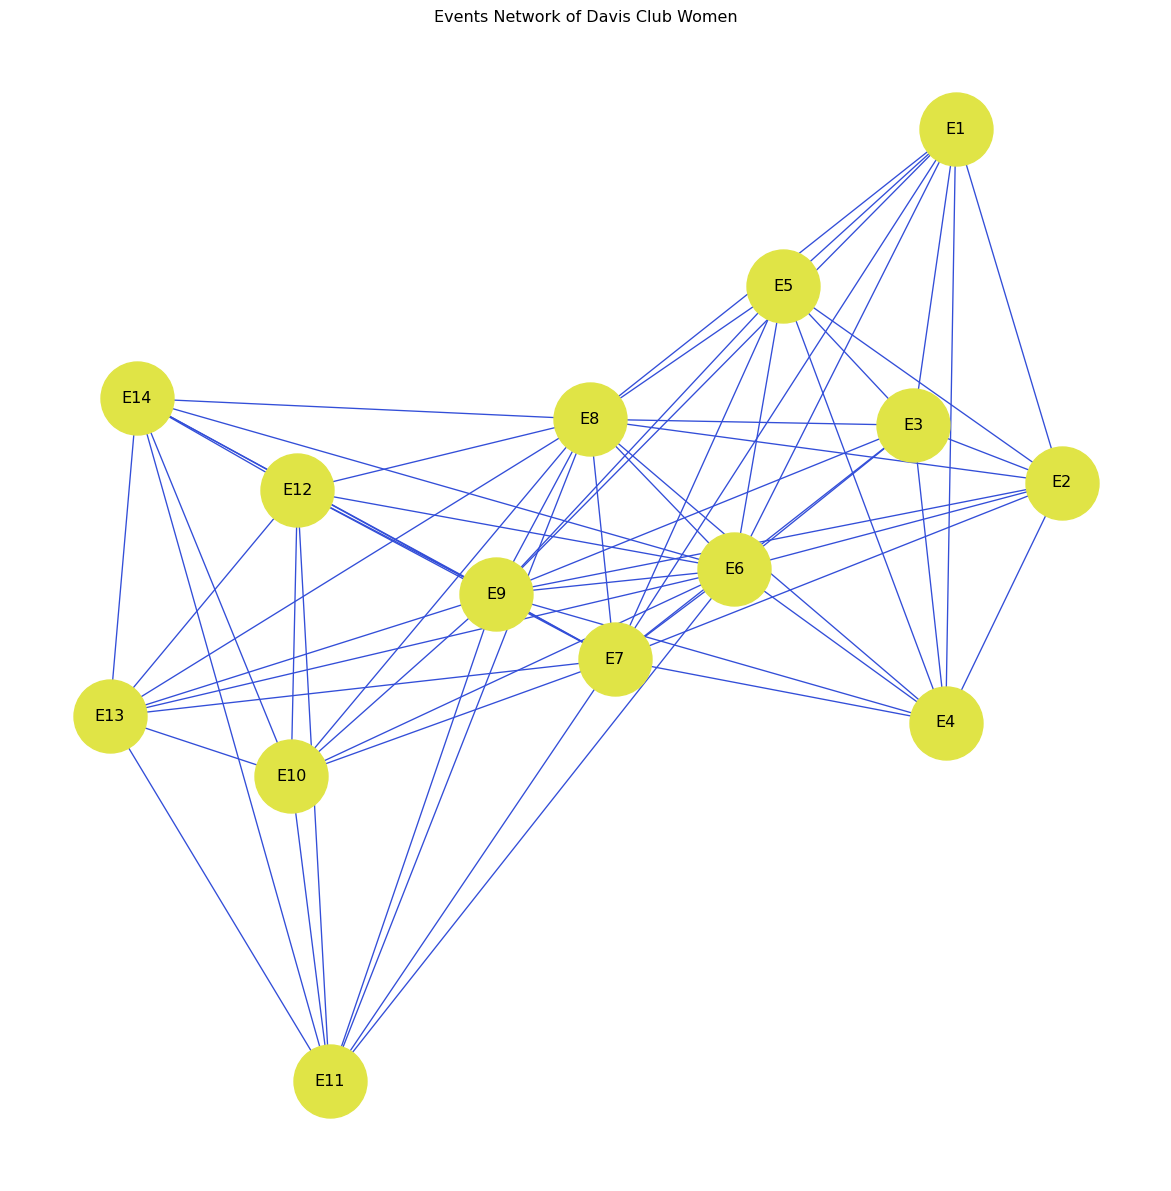

In [12]:
#-- overlap matrix--
event_rel= matrix_a.T @ matrix_a

#--removing the diag values--
np.fill_diagonal(event_rel.values, 0)
event_g= nx.from_pandas_adjacency(event_rel)

#--visualizing--
plt.figure(figsize= (12,12))
nx.draw(event_g, with_labels=True, node_color= "#E0E446", node_size=3000, edge_color= "#334ED8", font_size=12)
plt.title("Events Network of Davis Club Women")
plt.show()

The network has some slight clustering:

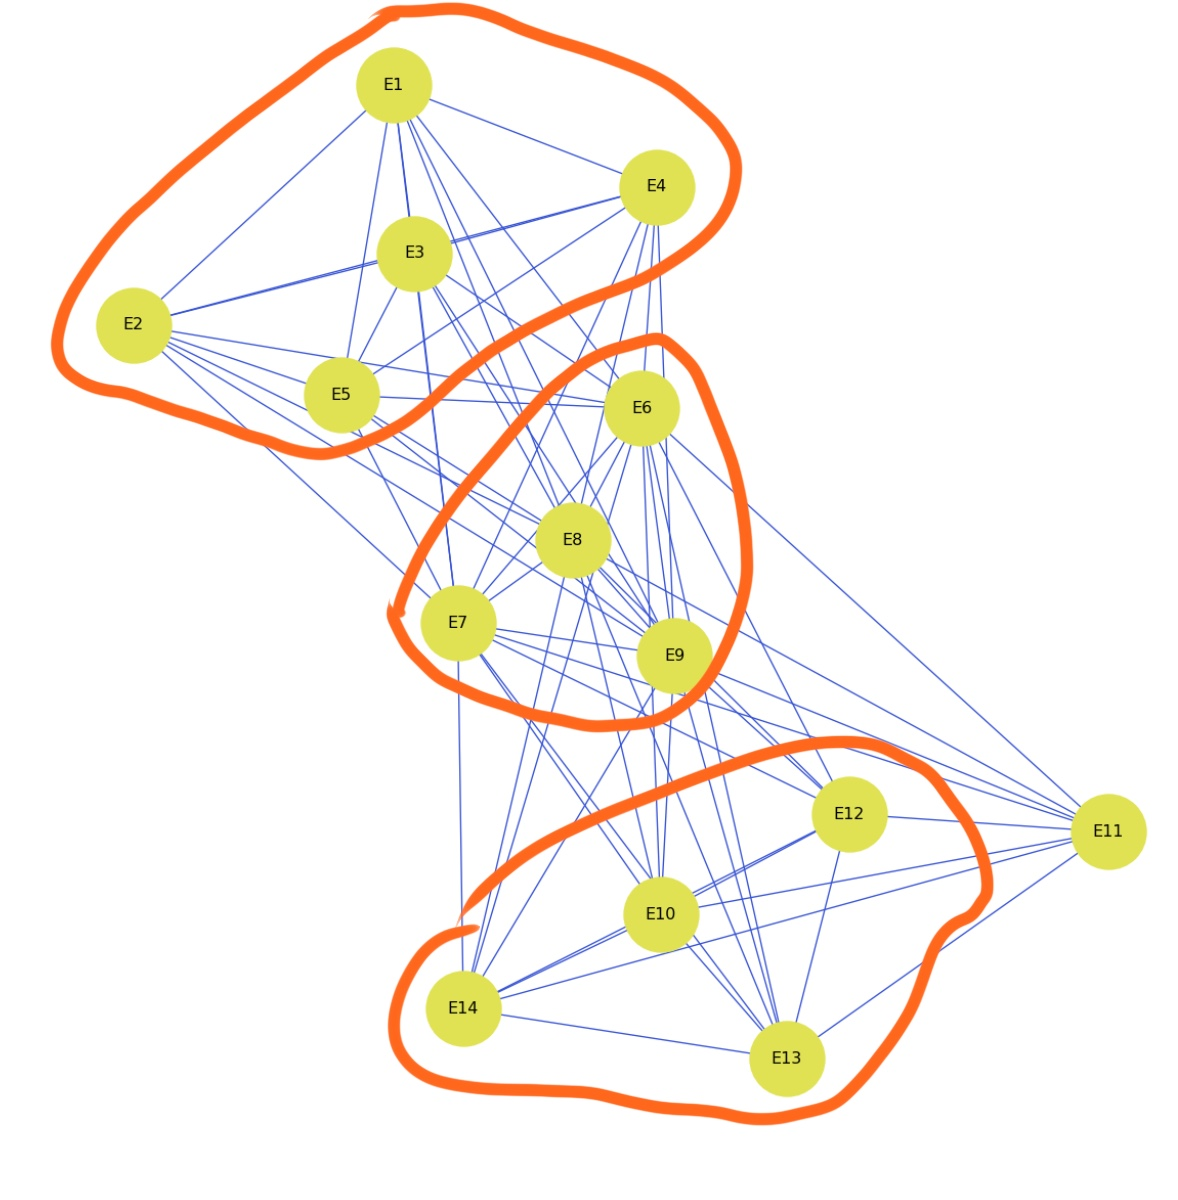

We’ll continue by trimming and using the output to infer:

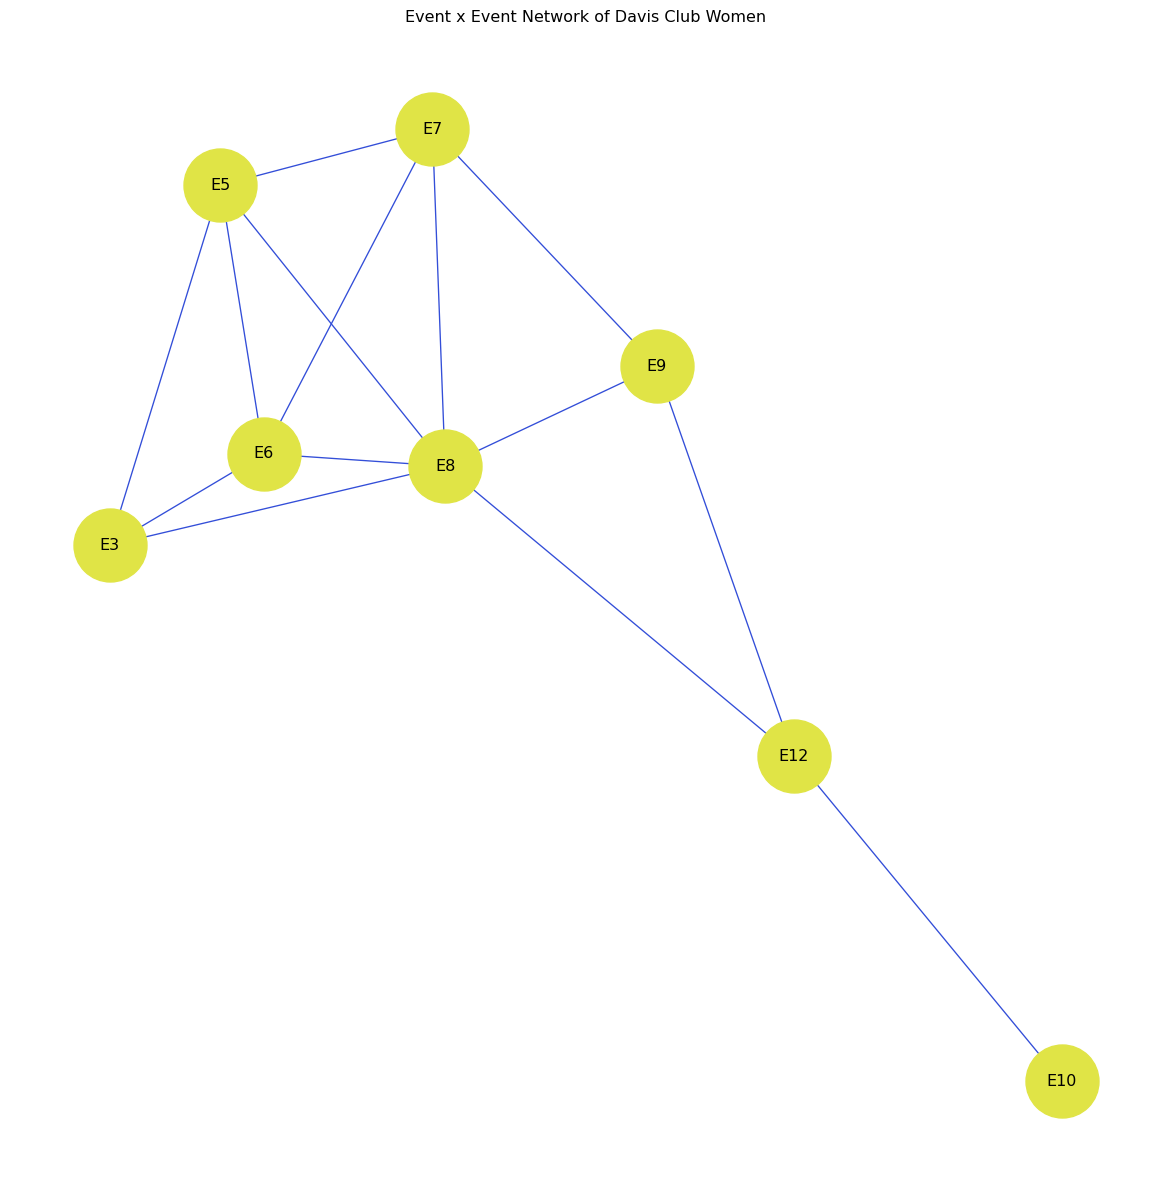

   source target  weight
65     E8     E9       9
63     E7     E8       8
61     E6     E8       7
58     E5     E8       7
56     E5     E6       6

In [13]:
#--picking a threshold--
weights2= list(nx.get_edge_attributes(event_g, "weight").values())
pd.Series(weights2).value_counts().sort_index()

#-- trim function--
trimmed2= trim_edges(event_g, weight= 4)

#--visualizing--
plt.figure(figsize= (12,12))
nx.draw(trimmed2, with_labels=True, node_color= "#E0E446", node_size=3000, edge_color= "#334ED8", font_size=12)
plt.title("Event x Event Network of Davis Club Women")
plt.show()

#--List
event_edges= nx.to_pandas_edgelist(event_g).sort_values("weight", ascending=False)
print(event_edges.head(5))

E8 appears 4 times and is identified as central, connecting directly to
E5, E6, E7, and E9.

## Conclusion

In modifying a two mode network, into a one mode network, one can gain
accurate insights into social networks’ relationship structure. The
island method helps identify relationships that are most central by
implementing a threshold. Within the Davis Club member relationship
structure, we can infer that some of the women have these *island*
connections. I think Brenda, Evelyn, and Katherina are central to inner
social circles within the club. We can also infer that Event 8 was a hub
within the events network, many of of the same members attended along
with the events E8 was tied to (6,7,8 and 9).

------------------------------------------------------------------------

## Bibliography:

Tsvetovat, M., & Kouznetsov, A. (2011). Social Network Analysis for
Startups: Finding connections on the social web (1st ed.). O’Reilly
Media.

Social Network Analysis: Analyzing Two-Mode Networks:

<https://www.youtube.com/watch?v=o0Mxjll7-6o>